In [1]:
words = open('names.txt').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

## Bigram

In [6]:
b = {} # Dictionary to hold bigram counts
for w in words:
    chrs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chrs, chrs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

sorted(b.items(), key=lambda x: x[1], reverse=True)

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [13]:
import torch
import matplotlib.pyplot as plt

In [24]:
N = torch.zeros((27,27), dtype= torch.int32) # 27x27 matrix to hold bigram counts, 26 letters + start and end tokens

In [25]:
chars = sorted(list(set(''.join(words)))) # Get unique characters from the words and sort them
stoi = {s:i+1 for i,s in enumerate(chars)} # Create a mapping from characters to indices
stoi['.'] = 0

In [26]:
# Populate the bigram count matrix N using the words and the stoi mapping
for w in words:
    chrs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chrs, chrs[1:]):
        i1 = stoi[ch1]
        i2 = stoi[ch2]
        N[i1, i2] += 1

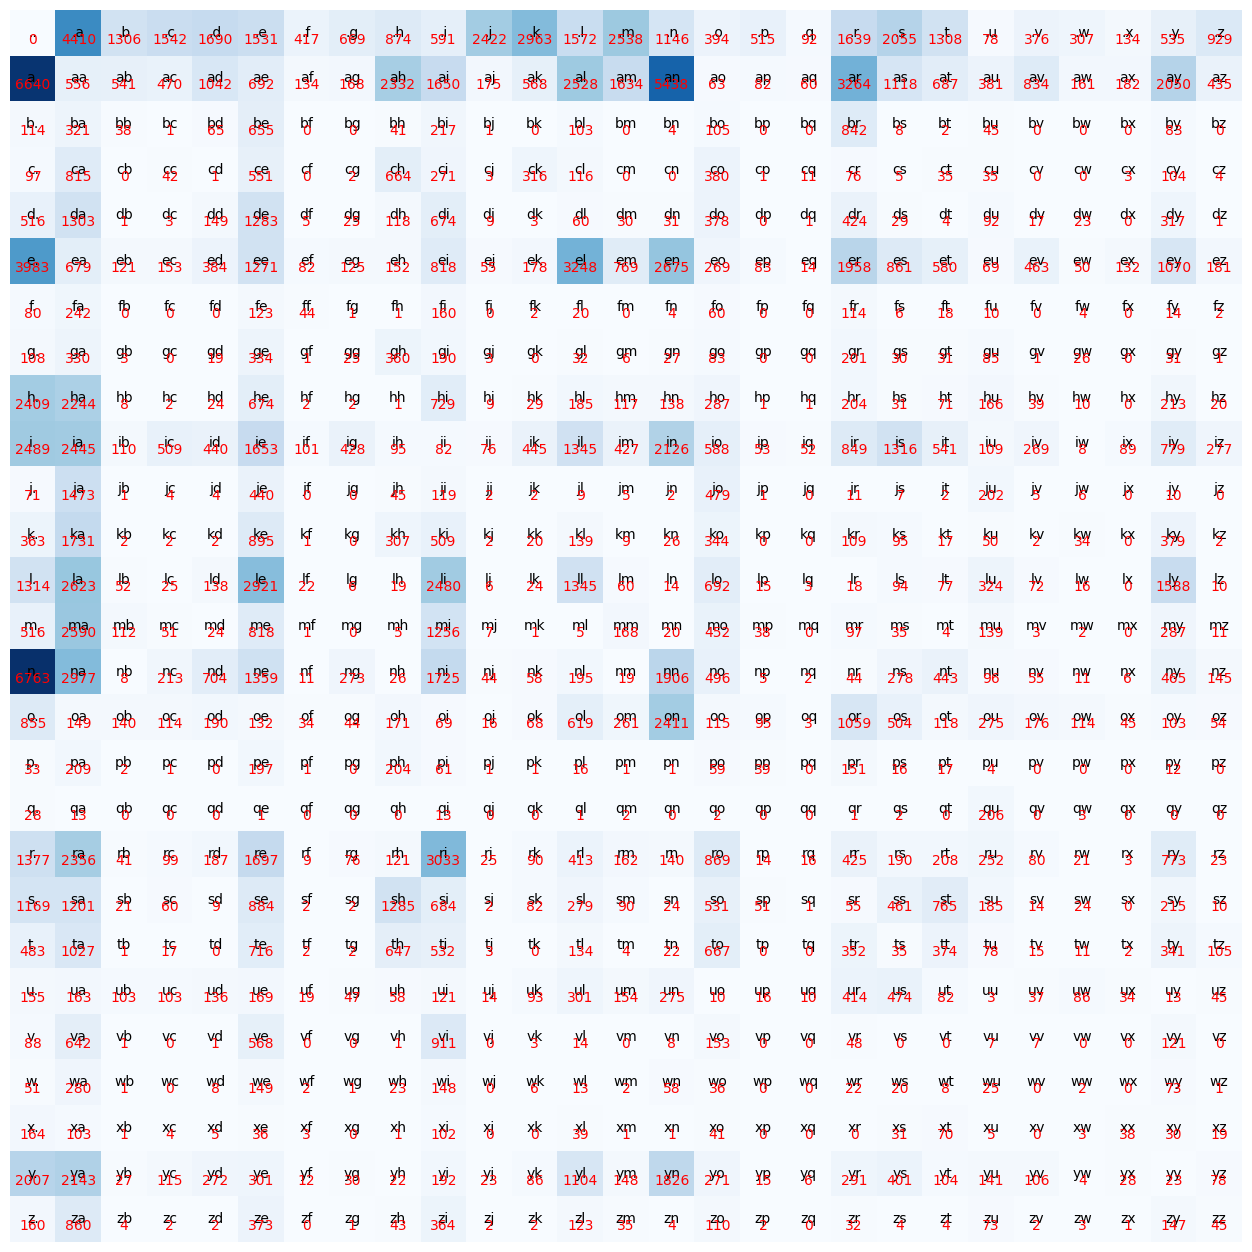

In [27]:
itos = {i:s for s,i in stoi.items()} # Create a mapping from indices to characters

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='center')
        plt.text(j, i, N[i,j].item(), ha='center', va='top', color='red')
plt.axis('off')
plt.show()

Converting counts into probability

In [33]:
p = N[0].float() # Get the counts of bigrams starting with the start token
p = p / p.sum() # Normalize to get probabilities
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [36]:
g = torch.Generator().manual_seed(2147483647) # Create a random generator with a fixed seed for reproducibility
x = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item() # Sample the next character based on the probabilities
itos[x] # Convert the sampled index back to a character

'c'

In [39]:
g = torch.Generator().manual_seed(2147483647) # Create a random generator with a fixed seed for reproducibility
ix = 0
for i in range(10):
    out = []
    while True:
        p = N[ix].float()
        p = p / p.sum()
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        if ix == 0:
            break
        out.append(itos[ix])

    print(''.join(out))    

cexze
momasurailezitynn
konimittain
llayn
ka
da
staiyaubrtthrigotai
moliellavo
ke
teda


Efficiency, vectorized normalization of the rows

In [54]:
P = (N+1).float() # Add 1 to each count for Laplace/model smoothing to avoid zero probabilities
P /= P.sum(1, keepdim=True) # Normalize each row to get probabilities, this uses broadcasting to divide each element in a row by the sum of that row
P[0] # Get the probabilities of bigrams starting with the start token

tensor([3.1192e-05, 1.3759e-01, 4.0767e-02, 4.8129e-02, 5.2745e-02, 4.7785e-02,
        1.3038e-02, 2.0898e-02, 2.7293e-02, 1.8465e-02, 7.5577e-02, 9.2452e-02,
        4.9064e-02, 7.9195e-02, 3.5777e-02, 1.2321e-02, 1.6095e-02, 2.9008e-03,
        5.1154e-02, 6.4130e-02, 4.0830e-02, 2.4641e-03, 1.1759e-02, 9.6070e-03,
        4.2109e-03, 1.6719e-02, 2.9008e-02])

In [55]:
g = torch.Generator().manual_seed(2147483647) # Create a random generator with a fixed seed for reproducibility
ix = 0
for i in range(10):
    out = []
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        if ix == 0:
            break
        out.append(itos[ix])

    print(''.join(out))    

cexze
momasurailezitynn
konimittain
llayn
ka
da
staiyaubrtthrigotai
moliellavo
ke
teda


## Loss Function

* GOAL: maximize likelihood of the data w.r.t model parameters (statistical modeling).
* equivalent to maximizing the log likelihood (because log is monotonic)
* equivalent to minimizing the negative log likelihood
* equivalent to minimizing the average negative log likelihood

log(a X b X c) = log(a) + log(b) + log(c)

In [56]:
log_likelihood = 0.0
n = 0
for w in words:
    chrs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chrs, chrs[1:]):
        i1 = stoi[ch1]
        i2 = stoi[ch2]
        prob = P[i1, i2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        # print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

log_likelihood=tensor(-559951.5625)
nll=tensor(559951.5625)
2.4543561935424805


Likelihood is the product of all the probabilities. 

The probabilty of the entire dataset assigned by the model we have trained and that is the measure of quality.

For convenience we work with the log likelihood 

Therefore, the loss function assigned by the model is 2.454 that is the quality of the model and the lower it is the better.